<a href="https://colab.research.google.com/github/tejinderpa/Deep-Learning/blob/Going-Deep/keras_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.shape

(768, 9)

In [5]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
60,2,84,0,0,0,0.0,0.304,21,0
208,1,96,64,27,87,33.2,0.289,21,0
507,1,130,60,23,170,28.6,0.692,21,0
483,0,84,82,31,125,38.2,0.233,23,0
554,1,84,64,23,115,36.9,0.471,28,0


In [8]:
df.corr()['Outcome'].sort_values(ascending = False)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


In [9]:
X = df.iloc[:, :-1]

In [10]:
y = df.iloc[:, -1]

In [12]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size = 0.2,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [14]:
xtrain_scaled = ss.fit_transform(xtrain)
xtest_scaled = ss.transform(xtest)

In [15]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

In [17]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.6 MB/s eta 0:00:00


In [18]:
import keras_tuner as kt

In [19]:
def build_model(hp):
    model = Sequential()

    counter = 0

    for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int('units' + str(i),min_value=8,max_value=128,step=8),
                    activation=hp.Choice(
                        'activation'+str(i), values=['relu','sigmoid','tanh']),
                    input_dim=8)
                )
            model.add(
                Dropout(
                    hp.Choice(
                        'dropout' + str(i), values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))

        else:
            model.add(Dense(hp.Int('units' + str(i),min_value=8,max_value=128,step=8),activation=hp.Choice('activation'+str(i),values=['relu','sigmoid','tanh'])))
            model.add(Dropout(hp.Choice('dropout' + str(i), values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))


        counter += 1


    model.add(Dense(1,activation='sigmoid'))
    model.compile(loss = 'binary_crossentropy',optimizer=hp.Choice('optimizer',values=['rmsprop','adam','sgd','nadam','adelta']),metrics=['accuracy'])

    return model

In [20]:
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=3)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
tuner.search(xtrain_scaled,ytrain,epochs=5,validation_data=(xtest_scaled,ytest))

Trial 3 Complete [00h 00m 01s]

Best val_accuracy So Far: 0.701298713684082
Total elapsed time: 00h 00m 13s


In [22]:
tuner.get_best_hyperparameters()[0].values


{'num_layers': 4,
 'units0': 48,
 'activation0': 'tanh',
 'dropout0': 0.3,
 'optimizer': 'nadam',
 'units1': 8,
 'activation1': 'relu',
 'dropout1': 0.1,
 'units2': 8,
 'activation2': 'relu',
 'dropout2': 0.1,
 'units3': 8,
 'activation3': 'relu',
 'dropout3': 0.1}

In [23]:
model = tuner.get_best_models(num_models=1)[0]


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 23 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 977 (3.82 KB)

 Trainable params: 977 (3.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(xtrain_scaled,ytrain,epochs = 200,initial_epoch=6,validation_data=(xtest_scaled,ytest))


Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6221 - loss: 0.6641 - val_accuracy: 0.6753 - val_loss: 0.6334
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6695 - loss: 0.6445 - val_accuracy: 0.6753 - val_loss: 0.6070
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6769 - loss: 0.6046 - val_accuracy: 0.6688 - val_loss: 0.5794
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6383 - loss: 0.5938 - val_accuracy: 0.7013 - val_loss: 0.5550
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6833 - loss: 0.5440 - val_accuracy: 0.7208 - val_loss: 0.5368
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6575 - loss: 0.5737 - val_accuracy: 0.7208 - val_loss: 0.5257
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6866 - loss: 0.5472 - val_accuracy: 0.7468 - val_loss: 0.5149
Epoch 14/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6949 - loss: 0.5327 - val_accuracy: 0.75

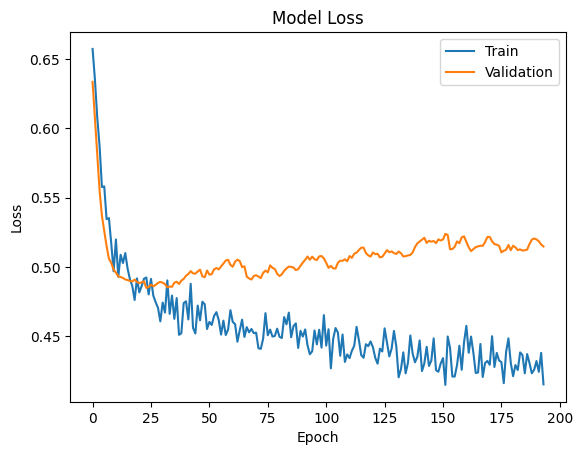

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [32]:
def build_model(hp):
    model = Sequential()

    counter = 0

    for i in range(hp.Int('num_layers',min_value=1,max_value=15)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int('units' + str(i),min_value=8,max_value=128,step=1),
                    activation=hp.Choice(
                        'activation'+str(i), values=['relu','tanh', 'elu', 'selu']),
                    input_dim=8
                    )
                )
            model.add(
                Dropout(
                    hp.Choice(
                        'dropout' + str(i), values = [0.1,0.2,0.3,0.4])
                    )
                )

        else:
            model.add(
                Dense(
                    hp.Int('units' + str(i),min_value=8,max_value=128, step=1),
                    activation=hp.Choice(
                        'activation'+str(i), values=['relu','elu','tanh', 'selu']),
                    )
                )
            model.add(
                Dropout(
                    hp.Choice(
                        'dropout' + str(i), values = [0.1,0.2,0.3,0.4])
                    )
                )

        counter += 1


    model.add(Dense(1,activation='sigmoid'))
    model.compile(loss = 'binary_crossentropy',optimizer=hp.Choice('optimizer',values=['rmsprop','adam','sgd','nadam','adelta']),metrics=['accuracy'])

    return model

In [33]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=3,
    directory='project',
    project_name='Air Quality Index'
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
tuner.search(xtrain_scaled,ytrain,epochs=5,validation_data=(xtest_scaled,ytest))

Trial 5 Complete [00h 00m 13s]
val_accuracy: 0.6623376607894897

Best val_accuracy So Far: 0.7575757503509521
Total elapsed time: 00h 01m 23s


In [35]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 3,
 'units0': 52,
 'activation0': 'relu',
 'dropout0': 0.1,
 'optimizer': 'adam',
 'units1': 39,
 'activation1': 'tanh',
 'dropout1': 0.1,
 'units2': 62,
 'activation2': 'selu',
 'dropout2': 0.2,
 'units3': 89,
 'activation3': 'elu',
 'dropout3': 0.1,
 'units4': 122,
 'activation4': 'elu',
 'dropout4': 0.3,
 'units5': 102,
 'activation5': 'selu',
 'dropout5': 0.2,
 'units6': 51,
 'activation6': 'elu',
 'dropout6': 0.3,
 'units7': 42,
 'activation7': 'elu',
 'dropout7': 0.3,
 'units8': 80,
 'activation8': 'selu',
 'dropout8': 0.4,
 'units9': 119,
 'activation9': 'tanh',
 'dropout9': 0.3,
 'units10': 99,
 'activation10': 'elu',
 'dropout10': 0.3}

In [36]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [37]:
model.fit(xtrain_scaled,ytrain,epochs=200,initial_epoch=6,validation_data=(xtest_scaled,ytest))

Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7470 - loss: 0.5291 - val_accuracy: 0.7468 - val_loss: 0.5142
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7794 - loss: 0.4607 - val_accuracy: 0.7662 - val_loss: 0.5086
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7703 - loss: 0.4799 - val_accuracy: 0.7403 - val_loss: 0.5119
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7967 - loss: 0.4620 - val_accuracy: 0.7403 - val_loss: 0.5139
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7922 - loss: 0.4363 - val_accuracy: 0.7532 - val_loss: 0.5137
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7777 - loss: 0.4751 - val_accuracy: 0.7403 - val_loss: 0.5189
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7658 - loss: 0.4769 - val_accuracy: 0.7338 - val_loss: 0.5256
Epoch 14/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7812 - loss: 0.4425 - val_accuracy

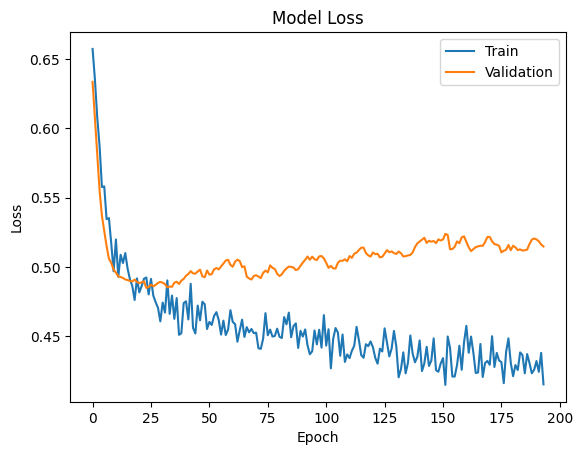

In [38]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()